In [2]:
"""Evaluate a models testing keyrank at N traces and how many traces required to achieve 99% accuracy"""

import data
import sys
import numpy as np
import torch
import json

import training

import keyrank_rs

import torch.nn as nn

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [3]:
def metadata_best_epoch(model_name) -> int:
    with open(f"models/{model_name}/metadata.json") as f:
        metadata = json.load(f)
        val_scores = metadata["scores"][1]
        best_epoch = np.array(val_scores).argmin()
    return best_epoch.item()

In [31]:
device = torch.device("cuda")

IMPL = "fixslice"
PREDICTION_TARGET = "sbox"
TARGET_BYTE_IDX = 1
ARCH = "zhang"

TRACE_START = 400
TRACE_END = 1500

SEED = 777

_,_,test_loader = data.get_dataloaders(
    200,
    PREDICTION_TARGET,
    TARGET_BYTE_IDX,
    TRACE_START,
    TRACE_END,
    SEED,
)

model_name = f"{IMPL}-{PREDICTION_TARGET}-byte{TARGET_BYTE_IDX}-{ARCH}-{TRACE_START}_{TRACE_END}-s{SEED}"
epoch = metadata_best_epoch(model_name)

model_path = f"models/{model_name}/epoch{epoch}.pt"

print(model_path)

model = torch.load(model_path).to(device)

models/fixslice-sbox-byte1-zhang-400_1500-s777/epoch32.pt


/tmp/ipykernel_5822/475662429.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path).to(device)


In [ ]:
"""Keyrank progression for sbox"""

from tqdm import tqdm

BLOCK = 0
MAX_TRACES = 50
N_KEYS = 500

log_softmax = nn.LogSoftmax(dim=1)

total_hits = torch.zeros(MAX_TRACES)

for key_idx, (traces, plaintexts, true_key) in tqdm(enumerate(test_loader), total=N_KEYS):

    plaintexts = plaintexts[:, :, BLOCK].squeeze().long().detach().cpu().numpy()
    traces = traces.squeeze()[:MAX_TRACES].to(device)

    sbox_scores = model(traces)
    numpy_sbox_scores = sbox_scores.detach().cpu().numpy()

    numpy_keyscores = keyrank_rs.sbox_scores_to_keyscores_parallel(plaintexts, numpy_sbox_scores)

    x = torch.Tensor(numpy_keyscores)
    x = log_softmax(x)
    x = x.cumsum(dim=0)
    ranks = (x.argsort(descending = True, dim=1) == true_key).nonzero()[:, 1]

    total_hits = total_hits + ranks

mean_ranks_sbox = total_hits / N_KEYS
    

100%|██████████| 500/500 [00:03<00:00, 163.34it/s]


In [26]:
"""Accuracy progression for sbox"""

from tqdm import tqdm

MAX_TRACES = 50
N_KEYS = 500

log_softmax = nn.LogSoftmax(dim=1)

total_hits = torch.zeros(MAX_TRACES)

for key_idx, (traces, plaintexts, true_key) in tqdm(enumerate(test_loader), total=N_KEYS):

    plaintexts = plaintexts[:, :, BLOCK].squeeze().long().detach().cpu().numpy()
    traces = traces.squeeze()[:MAX_TRACES].to(device)

    sbox_scores = model(traces)
    numpy_sbox_scores = sbox_scores.detach().cpu().numpy()

    numpy_keyscores = keyrank_rs.sbox_scores_to_keyscores_parallel(plaintexts, numpy_sbox_scores)

    x = torch.Tensor(numpy_keyscores)
    x = log_softmax(x)
    x = x.cumsum(dim=0)
    hits = (x.argsort(descending = True, dim=1)[:, 0] == true_key)

    total_hits = total_hits + hits

accs_sbox = total_hits / N_KEYS
    

100%|██████████| 500/500 [00:02<00:00, 184.89it/s]


In [27]:
(accs_sbox > 0.99).nonzero()[0] + 1

tensor([26])

tensor([7])


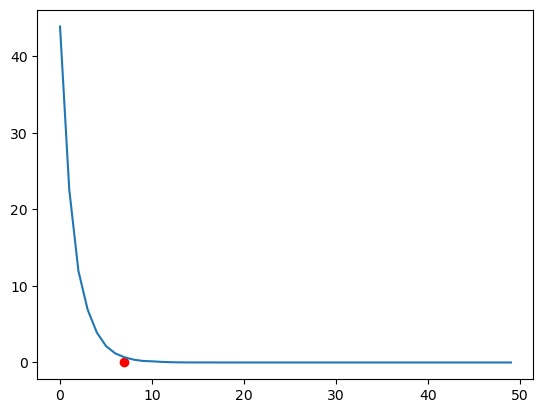

In [15]:
import matplotlib.pyplot as plt

first0 = (mean_ranks_sbox < 1.).nonzero()[0]

plt.plot(mean_ranks_sbox)
plt.scatter([first0], [0.], color='red')

print(first0)


In [ ]:
"""Keyrank progression for 2sbox"""

from tqdm import tqdm

MAX_TRACES = 50
N_KEYS = 500

log_softmax = nn.LogSoftmax(dim=1)

total_hits = torch.zeros(MAX_TRACES)

for key_idx, (traces, plaintexts, true_key) in tqdm(enumerate(test_loader), total=N_KEYS):

    block1_plaintexts = plaintexts[:, :, 0].squeeze().long().detach().cpu().numpy()
    block2_plaintexts = plaintexts[:, :, 1].squeeze().long().detach().cpu().numpy()

    traces = traces.squeeze()[:MAX_TRACES].to(device)

    sbox_scores1, sbox_scores2 = model(traces)

    numpy_sbox_scores1 = sbox_scores1.detach().cpu().numpy()
    numpy_sbox_scores2 = sbox_scores2.detach().cpu().numpy()

    numpy_keyscores1 = keyrank_rs.sbox_scores_to_keyscores_parallel(block1_plaintexts, numpy_sbox_scores1)
    numpy_keyscores2 = keyrank_rs.sbox_scores_to_keyscores_parallel(block2_plaintexts, numpy_sbox_scores2)

    x = torch.Tensor(numpy_keyscores1 + numpy_keyscores2)
    x = log_softmax(x)

    #x1 = torch.Tensor(numpy_keyscores1)
    #x2 = torch.Tensor(numpy_keyscores2)
    #x = log_softmax(x1) + log_softmax(x2)

    x = x.cumsum(dim=0)
    ranks = (x.argsort(descending = True, dim=1) == true_key).nonzero()[:, 1]

    total_hits = total_hits + ranks

mean_ranks_2sbox = total_hits / N_KEYS
    

100%|██████████| 500/500 [00:03<00:00, 162.30it/s]


In [29]:
"""Accuracy progression for 2sbox"""

from tqdm import tqdm

MAX_TRACES = 50
N_KEYS = 500

log_softmax = nn.LogSoftmax(dim=1)

total_hits = torch.zeros(MAX_TRACES)

for key_idx, (traces, plaintexts, true_key) in tqdm(enumerate(test_loader), total=N_KEYS):

    block1_plaintexts = plaintexts[:, :, 0].squeeze().long().detach().cpu().numpy()
    block2_plaintexts = plaintexts[:, :, 1].squeeze().long().detach().cpu().numpy()

    traces = traces.squeeze()[:MAX_TRACES].to(device)

    sbox_scores1, sbox_scores2 = model(traces)

    numpy_sbox_scores1 = sbox_scores1.detach().cpu().numpy()
    numpy_sbox_scores2 = sbox_scores2.detach().cpu().numpy()

    numpy_keyscores1 = keyrank_rs.sbox_scores_to_keyscores_parallel(block1_plaintexts, numpy_sbox_scores1)
    numpy_keyscores2 = keyrank_rs.sbox_scores_to_keyscores_parallel(block2_plaintexts, numpy_sbox_scores2)

    x = torch.Tensor(numpy_keyscores1 + numpy_keyscores2)
    x = log_softmax(x)

    #x1 = torch.Tensor(numpy_keyscores1)
    #x2 = torch.Tensor(numpy_keyscores2)
    #x = log_softmax(x1) + log_softmax(x2)

    x = x.cumsum(dim=0)
    hits = (x.argsort(descending = True, dim=1)[:, 0] == true_key)

    total_hits = total_hits + hits

accs_2sbox = total_hits / N_KEYS
    

100%|██████████| 500/500 [00:02<00:00, 181.47it/s]


In [30]:
(accs_2sbox > 0.99).nonzero()[0] + 1

tensor([27])

tensor([3])


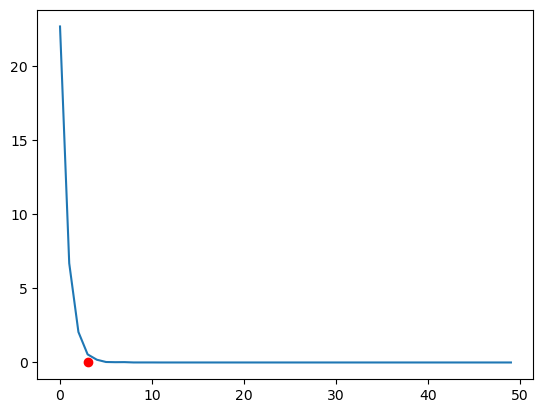

In [67]:
import matplotlib.pyplot as plt

first0 = (mean_ranks_2sbox < 1.).nonzero()[0]

plt.plot(mean_ranks_2sbox)
plt.scatter([first0], [0.], color='red')

print(first0)
